In [68]:
import pandas as pd
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dython.nominal import associations
from sklearn.preprocessing import LabelEncoder

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False



In [43]:
train_path='open/train'
associations_df_list=[]
df_list=[]
for x in ['1.회원정보','6.채널정보','8.성과정보']:
    nxt_path=os.path.join(train_path,x)
    df_list1=[]
    for y in os.listdir(nxt_path):
        if False:
            file_path=os.path.join(nxt_path,y)
            df=pd.read_parquet(file_path)[['ID','기준년월','Segment']]
            print(df.columns)
            df_list1.append(df)
        else:
            file_path=os.path.join(nxt_path,y)
            df=pd.read_parquet(file_path)
            df=df.dropna(axis=1)
            df_list1.append(df)
        
        print(y)
        gc.collect()
    df=pd.concat(df_list1,ignore_index=True)
    df_list.append(df)
df=pd.merge(left=df_list[0],right=df_list[1],on=['ID','기준년월'])
df=pd.merge(left=df,right=df_list[2],on=['ID','기준년월'])

201807_train_회원정보.parquet
201808_train_회원정보.parquet
201809_train_회원정보.parquet
201810_train_회원정보.parquet
201811_train_회원정보.parquet
201812_train_회원정보.parquet
201807_train_채널정보.parquet
201808_train_채널정보.parquet
201809_train_채널정보.parquet
201810_train_채널정보.parquet
201811_train_채널정보.parquet
201812_train_채널정보.parquet
201807_train_성과정보.parquet
201808_train_성과정보.parquet
201809_train_성과정보.parquet
201810_train_성과정보.parquet
201811_train_성과정보.parquet
201812_train_성과정보.parquet


In [41]:
# LabelEncoder 하기
le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col].astype(str))


# 상관관계 분석
# correlations = df.corr()
# correlations.to_csv("data/correlations.csv",encoding='utf-8-sig')

In [ ]:

# Segment와 관련 있는 상위 15개 변수만 선택
top_features = correlations.abs().sort_values(ascending=False).head(15).index
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상위 15개 변수 간 상관관계 히트맵")
plt.show()


In [33]:

numeric_cols = df.select_dtypes(include=np.number).columns
other_numeric_cols = numeric_cols.drop('Target_Column', errors='ignore')

target_series = df['Segment']

# 상관계수를 저장할 딕셔너리 초기화
correlations = {}



# 각 열과 Target_Column 간의 상관계수 계산
for col in other_numeric_cols:
    correlations[col] = target_series.corr(df[col])




print("-" * 30)

# 딕셔너리를 Pandas Series로 변환
correlations_series = pd.Series(correlations)

print("\n'Target_Column'과 다른 열과의 상관계수 (정렬 전):")
print(correlations_series.head()) # 앞부분만 출력하여 확인
print("...")
print("-" * 30)

# 상관계수 Series를 절대값 기준으로 내림차순 정렬
# `key=abs`를 사용하여 절대값으로 정렬하되, 원본 값은 유지합니다.
# `ascending=False`로 가장 강한 상관관계(절대값이 큰)부터 정렬합니다.
sorted_correlations = correlations_series.sort_values(key=abs, ascending=False)

print("\n'Target_Column'과 다른 열과의 상관계수 (절대값 기준으로 내림차순 정렬):")
print(sorted_correlations.head(10)) # 상위 10개 출력
print("...")
print("-" * 30)

# 만약 자기 자신과의 상관계수(1.0)를 포함해야 한다면, 위 코드에서는 'Target_Column'을 제외했으므로
# 수동으로 추가하거나, `other_numeric_cols`를 만들 때 `drop`하지 않으면 됩니다.
# 예를 들어, 자기 자신을 포함하여 정렬하고 싶다면:
# all_correlations_including_self = pd.Series({col: target_series.corr(df[col]) for col in numeric_cols})
# sorted_correlations_including_self = all_correlations_including_self.sort_values(key=abs, ascending=False)

C:\Users\katch\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\katch\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


------------------------------

'Target_Column'과 다른 열과의 상관계수 (정렬 전):
ID                1.218077e-03
기준년월             -1.346381e-18
Segment           1.000000e+00
인입횟수_ARS_R6M      1.092171e-01
이용메뉴건수_ARS_R6M    4.280860e-02
dtype: float64
...
------------------------------

'Target_Column'과 다른 열과의 상관계수 (절대값 기준으로 내림차순 정렬):
Segment               1.000000
잔액_신판ca최대한도소진율_r6m   -0.268486
잔액_신판ca최대한도소진율_r3m   -0.263688
잔액_신판ca평균한도소진율_r3m   -0.258636
잔액_신판ca평균한도소진율_r6m   -0.252525
잔액_신판최대한도소진율_r6m     -0.200087
잔액_신판최대한도소진율_r3m     -0.194820
잔액_신판평균한도소진율_r3m     -0.189758
잔액_신판평균한도소진율_r6m     -0.181995
불만제기후경과월_R12M        -0.173899
dtype: float64
...
------------------------------


In [35]:
sorted_correlations=sorted_correlations.dropna()
sorted_correlations.to_csv("data/6_채널정보_8_성과정보.csv",encoding='utf-8-sig')

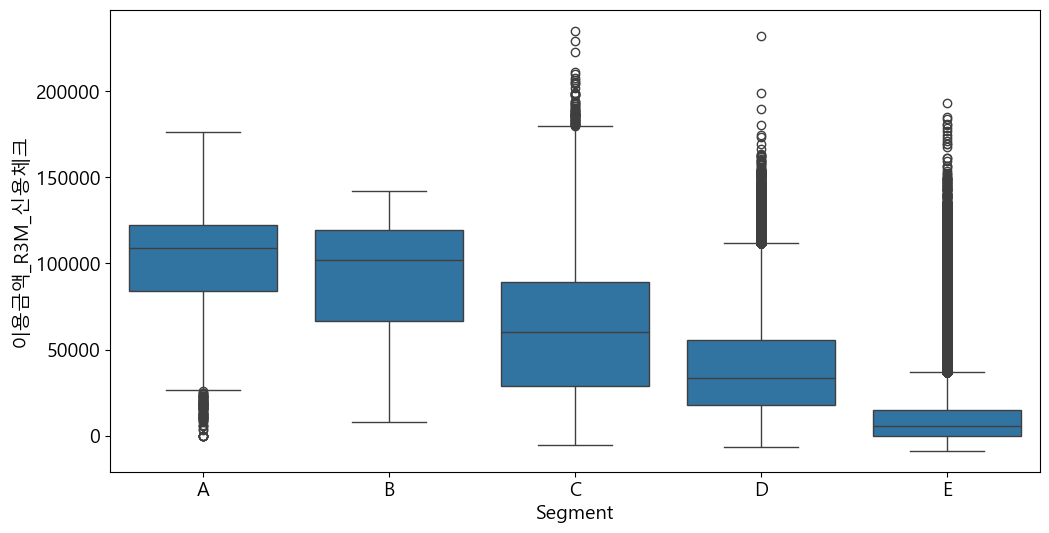

In [70]:
sns.boxplot(data=df,x="Segment",y='이용금액_R3M_신용체크',order=['A','B','C','D','E'])
plt.show()